In [ ]:
from google.colab import files
uploaded = files.upload()

Saving wdbc.data to wdbc.data


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('wdbc.data',header=None)

In [ ]:
# Show the first few rows
print(df.head())

# Check the shape
print(df.shape)


         0  1      2      3       4       5        6        7       8   \
0    842302  M  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.3001   
1    842517  M  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.0869   
2  84300903  M  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.1974   
3  84348301  M  11.42  20.38   77.58   386.1  0.14250  0.28390  0.2414   
4  84358402  M  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.1980   

        9   ...     22     23      24      25      26      27      28      29  \
0  0.14710  ...  25.38  17.33  184.60  2019.0  0.1622  0.6656  0.7119  0.2654   
1  0.07017  ...  24.99  23.41  158.80  1956.0  0.1238  0.1866  0.2416  0.1860   
2  0.12790  ...  23.57  25.53  152.50  1709.0  0.1444  0.4245  0.4504  0.2430   
3  0.10520  ...  14.91  26.50   98.87   567.7  0.2098  0.8663  0.6869  0.2575   
4  0.10430  ...  22.54  16.67  152.20  1575.0  0.1374  0.2050  0.4000  0.1625   

       30       31  
0  0.4601  0.11890  
1  0.2750  0.08902  
2  0.

In [ ]:
# Features and labels
X = df.iloc[:, 2:]            # 30 features
y = df.iloc[:, 1].map({'B':0, 'M':1})  # 0=Benign, 1=Malignant

In [ ]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])

In [ ]:
# Train SVM
svm_clf = SVC(kernel='linear', C=1.0)
svm_clf.fit(X_train, y_train)

# Predictions
y_pred = svm_clf.predict(X_test)

SVM Accuracy: 0.9649122807017544

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



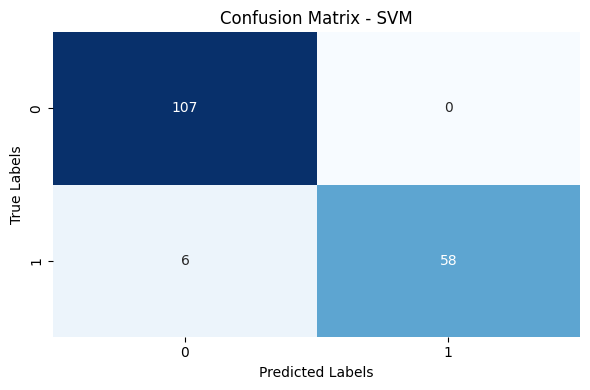

In [ ]:
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_clf.fit(X_train, y_train)

# Predictions and evaluation
y_pred = svm_clf.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=svm_clf.classes_, yticklabels=svm_clf.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - SVM')
plt.tight_layout()
plt.show()


Test Accuracy: 0.9649122807017544

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



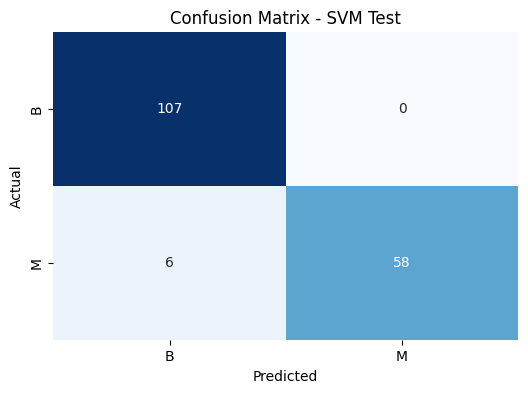

In [ ]:
#test
# Predict on test set
y_test_pred = svm_clf.predict(X_test)

# Evaluate accuracy and performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['B','M'], yticklabels=['B','M'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM Test')
plt.show()


In [ ]:
import numpy as np

# Example new sample (replace with actual values)
new_sample = np.array([[14.0, 20.0, 90.0, 600.0, 0.1, 0.2, 0.15, 0.1, 0.2, 0.05,
                        0.15, 0.2, 0.15, 0.2, 0.05, 0.3, 0.4, 0.3, 0.35, 0.1,
                        0.2, 0.3, 0.25, 0.35, 16.0, 25.0, 110.0, 800.0, 0.2, 0.5]])

# Standardize using the same scaler as training
new_sample_scaled = scaler.transform(new_sample)

# Predict
prediction = svm_clf.predict(new_sample_scaled)
print("Predicted class:", 'Malignant' if prediction[0]==1 else 'Benign')


Predicted class: Malignant


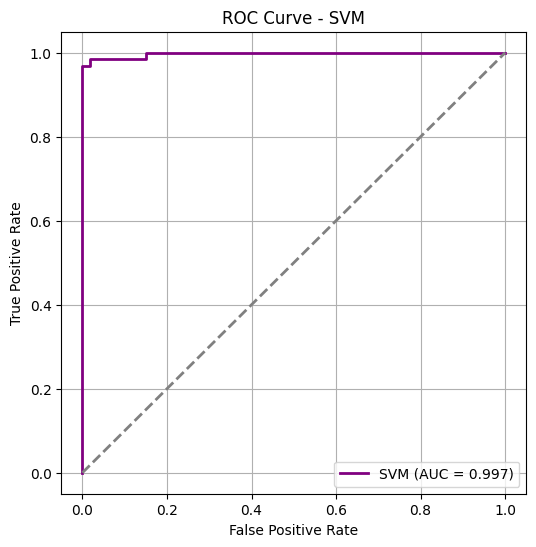

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- Step 1: Train SVM with probability enabled ---
svm = SVC(kernel="rbf", probability=True, random_state=42)
svm.fit(X_train, y_train)

# --- Step 2: Predict probabilities ---
y_proba_svm = svm.predict_proba(X_test)[:, 1]   # probability of positive class

# --- Step 3: ROC curve ---
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_proba_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# --- Step 4: Plot ---
plt.figure(figsize=(6, 6))
plt.plot(fpr_svm, tpr_svm, color="purple", lw=2, label=f"SVM (AUC = {roc_auc_svm:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend(loc="lower right")
plt.grid()
plt.show()
